# 5.1.6 Model 6: K-Nearest Neighbors (KNN) Regressor

Trained on `X_train_scaled.csv` (log1p-transformed numeric features, per Section 3.11.2) since KNN is distance-based and therefore scale-sensitive, same reasoning as Linear Regression, Ridge, and SVR.

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import make_scorer
import sys, os
sys.path.append(os.path.dirname(os.path.abspath('__file__')))
from model_utils import evaluate_model, cross_validate_model

MODELLING_DIR = os.path.join("..", "data", "modelling")
MODEL_DIR = os.path.join("..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

X_train = pd.read_csv(os.path.join(MODELLING_DIR, "X_train_scaled.csv"))
X_test = pd.read_csv(os.path.join(MODELLING_DIR, "X_test_scaled.csv"))
y_train = pd.read_csv(os.path.join(MODELLING_DIR, "y_train.csv"))["price"]
y_test = pd.read_csv(os.path.join(MODELLING_DIR, "y_test.csv"))["price"]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")


X_train: (3004, 51) | X_test: (751, 51)


## Additional Feature Standardisation
log1p (Section 3.11) fixes per-feature skew but not cross-feature scale - e.g. Total Units still has a wider spread than Bathroom after log1p, which would dominate distance calculations. An additional `StandardScaler` is needed.

The scaler is wrapped with `KNeighborsRegressor` in a `Pipeline`, so it's refit on each CV fold's training portion only - no validation row influences its own scaling (same train-only-fit principle as Section 3.9-3.11, extended into CV). The final model still fits its scaler on the complete `X_train`.

## Hyperparameter Tuning
Tuned with `BayesSearchCV` over the `Pipeline` (continuous search space, `n_iter=50`, 5-fold CV on `X_train`), so the scaler is refit per fold. Since `y_train` is `log(price)`, a custom scorer converts predictions back to RM before scoring, same reasoning as Random Forest's tuning. `X_test` is not used here.

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical

def rm_scale_rmse(y_true_log, y_pred_log):
    y_true_rm = np.exp(y_true_log)
    y_pred_rm = np.exp(y_pred_log)
    return np.sqrt(np.mean((y_true_rm - y_pred_rm) ** 2))

rm_rmse_scorer = make_scorer(rm_scale_rmse, greater_is_better=False)
cv_splitter = KFold(n_splits=5, shuffle=True, random_state=42)

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor()),
])

search_spaces = {
    "knn__n_neighbors": Integer(1, 50),
    "knn__weights": Categorical(["uniform", "distance"]),
    "knn__p": Real(1.0, 5.0),
}

bayes_search = BayesSearchCV(
    knn_pipeline,
    search_spaces,
    n_iter=50,
    scoring=rm_rmse_scorer,
    cv=cv_splitter,
    n_jobs=-1,
    random_state=42,
)
bayes_search.fit(X_train, y_train)

print("Best params:", bayes_search.best_params_)
print(f"Best CV score (RM-scale RMSE): RM {-bayes_search.best_score_:,.0f}")


C:\Users\Low\AppData\Roaming\Python\Python313\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(1), 5.0, np.str_('distance')] before, using random point [np.int64(33), 4.989017075559005, 'uniform']
  warnings.warn(


C:\Users\Low\AppData\Roaming\Python\Python313\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(1), 5.0, np.str_('distance')] before, using random point [np.int64(21), 2.8349406274037388, 'distance']
  warnings.warn(


C:\Users\Low\AppData\Roaming\Python\Python313\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(1), 5.0, np.str_('distance')] before, using random point [np.int64(14), 4.713201152640206, 'uniform']
  warnings.warn(


C:\Users\Low\AppData\Roaming\Python\Python313\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(1), 5.0, np.str_('distance')] before, using random point [np.int64(19), 2.760582954327886, 'distance']
  warnings.warn(


C:\Users\Low\AppData\Roaming\Python\Python313\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(1), 5.0, np.str_('distance')] before, using random point [np.int64(14), 1.1539038429935156, 'distance']
  warnings.warn(


C:\Users\Low\AppData\Roaming\Python\Python313\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(1), 5.0, np.str_('distance')] before, using random point [np.int64(40), 4.385976315560908, 'distance']
  warnings.warn(


C:\Users\Low\AppData\Roaming\Python\Python313\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(1), 5.0, np.str_('distance')] before, using random point [np.int64(7), 2.9554277505153785, 'distance']
  warnings.warn(


Best params: OrderedDict({'knn__n_neighbors': 3, 'knn__p': 2.3256062742269568, 'knn__weights': 'distance'})
Best CV score (RM-scale RMSE): RM 205,596


## 5-fold Cross-Validation
Run on `X_train` only, using `bayes_search.best_estimator_` (the tuned Pipeline) - the scaler is re-fit per fold here too.

In [3]:
cv_results = cross_validate_model(
    bayes_search.best_estimator_,
    X_train, y_train, n_splits=5,
)


5-fold CV (mean +/- std):
  RMSE:  RM 205,627 +/- 19,776  (58.5% of median price)
  MAE:   RM 98,035 +/- 4,363
  MAPE:  23.0% +/- 1.4%
  R2:    0.5987 +/- 0.0255


## Train Final Model
`BayesSearchCV`'s `refit=True` already retrained the best Pipeline on the full `X_train` (`bayes_search.best_estimator_`), reused directly here. `X_test` is touched only once, below.

In [4]:
final_params = bayes_search.best_params_
model = bayes_search.best_estimator_

print("Final params:", final_params)
print("Model ready (reused from BayesSearchCV's refit=True).")


Final params: OrderedDict({'knn__n_neighbors': 3, 'knn__p': 2.3256062742269568, 'knn__weights': 'distance'})
Model ready (reused from BayesSearchCV's refit=True).


## Evaluate
Metrics computed on both train and test sets - the gap between them is needed for Section 6.2's overfitting/underfitting analysis.

In [5]:
train_metrics = evaluate_model(model, X_train, y_train, label="Train")
print()
test_metrics = evaluate_model(model, X_test, y_test, label="Test")


Train RMSE:  RM 6,749  (1.9% of median price)
Train MAE:   RM 1,135
Train MAPE:  0.3%
Train R2:    0.9996



Test RMSE:  RM 187,823  (52.2% of median price)
Test MAE:   RM 94,442
Test MAPE:  20.4%
Test R2:    0.6795


## Sanity check: permutation importance vs EDA (Section 4.5.2)
KNN has no `coef_`/`feature_importances_`, so permutation importance is used instead. Checks whether KNN's importances broadly agree with Section 4.5.2's EDA findings.

In [6]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    model, X_test, y_test, scoring="r2", n_repeats=10, random_state=42, n_jobs=-1,
)
importance_table = pd.Series(perm_result.importances_mean, index=X_test.columns).sort_values(ascending=False)
print("Top 15 features by permutation importance (mean R2 drop):")
print(importance_table.head(15))


Top 15 features by permutation importance (mean R2 drop):
Property Size                     0.063201
Bathroom                          0.047219
PropertyType_Flat                 0.043813
State_Sabah                       0.036550
PropertyType_Condominium          0.022895
PropertyType_Service_Residence    0.022272
Parking Lot                       0.021368
State_Unknown                     0.020689
State_Sarawak                     0.019470
State_Kuala_Lumpur                0.018878
State_Penang                      0.018168
Property Age                      0.015155
Total Units                       0.015137
# of Floors                       0.014708
Has_Hospital                      0.012674
dtype: float64


## Save Trained Model
`model` is the full Pipeline (StandardScaler + KNN), so this single file is enough for the Streamlit prototype (Section 8) to load and predict directly, without retraining or managing a separate scaler file.

In [7]:
import joblib
model_path = os.path.join(MODEL_DIR, "knn_model.pkl")
joblib.dump(model, model_path)
print(f"Model saved to {model_path}")

Model saved to ..\models\knn_model.pkl


## Hyperparameter Sensitivity Visualizations (Diagnostic)
Each hyperparameter is swept individually, holding the other two at their `BayesSearchCV`-selected values, using 5-fold CV RMSE. Diagnostic only - not used for selection.

## Effect of n_neighbors

5-fold CV (mean +/- std):
  RMSE:  RM 233,569 +/- 23,687  (66.4% of median price)
  MAE:   RM 107,316 +/- 3,585
  MAPE:  25.9% +/- 1.6%
  R2:    0.4788 +/- 0.0734


5-fold CV (mean +/- std):
  RMSE:  RM 214,393 +/- 21,268  (61.0% of median price)
  MAE:   RM 100,312 +/- 4,491
  MAPE:  23.6% +/- 1.0%
  R2:    0.5636 +/- 0.0315


5-fold CV (mean +/- std):
  RMSE:  RM 213,676 +/- 26,609  (60.8% of median price)
  MAE:   RM 97,634 +/- 4,665
  MAPE:  22.4% +/- 1.4%
  R2:    0.5693 +/- 0.0254


5-fold CV (mean +/- std):
  RMSE:  RM 218,177 +/- 30,378  (62.0% of median price)
  MAE:   RM 98,360 +/- 6,415
  MAPE:  22.3% +/- 1.4%
  R2:    0.5523 +/- 0.0310


5-fold CV (mean +/- std):
  RMSE:  RM 225,341 +/- 34,379  (64.1% of median price)
  MAE:   RM 100,141 +/- 7,035
  MAPE:  22.5% +/- 1.5%
  R2:    0.5234 +/- 0.0423


5-fold CV (mean +/- std):
  RMSE:  RM 232,218 +/- 36,056  (66.0% of median price)
  MAE:   RM 101,811 +/- 7,828
  MAPE:  22.7% +/- 1.6%
  R2:    0.4942 +/- 0.0457


5-fold CV (mean +/- std):
  RMSE:  RM 235,896 +/- 37,582  (67.1% of median price)
  MAE:   RM 102,858 +/- 8,011
  MAPE:  22.9% +/- 1.6%
  R2:    0.4788 +/- 0.0484


5-fold CV (mean +/- std):
  RMSE:  RM 239,828 +/- 37,924  (68.2% of median price)
  MAE:   RM 104,687 +/- 8,287
  MAPE:  23.4% +/- 1.8%
  R2:    0.4614 +/- 0.0480


5-fold CV (mean +/- std):
  RMSE:  RM 248,177 +/- 39,735  (70.6% of median price)
  MAE:   RM 107,728 +/- 8,378
  MAPE:  24.1% +/- 1.6%
  R2:    0.4235 +/- 0.0530


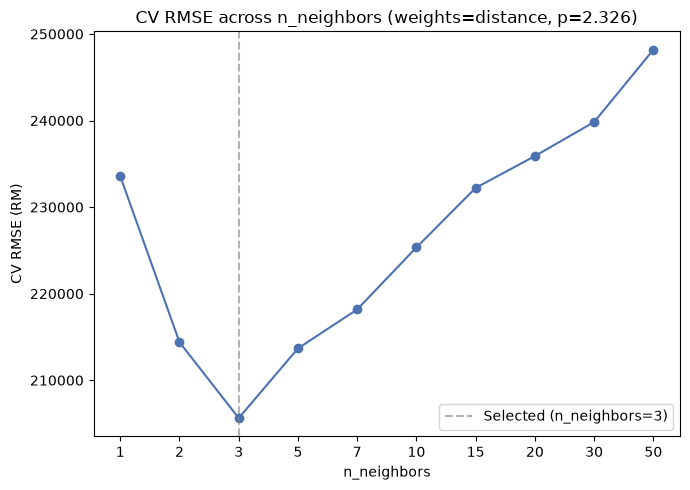

n_neighbors=1: CV RMSE=RM233,569
n_neighbors=2: CV RMSE=RM214,393
n_neighbors=3: CV RMSE=RM205,627
n_neighbors=5: CV RMSE=RM213,676
n_neighbors=7: CV RMSE=RM218,177
n_neighbors=10: CV RMSE=RM225,341
n_neighbors=15: CV RMSE=RM232,218
n_neighbors=20: CV RMSE=RM235,896
n_neighbors=30: CV RMSE=RM239,828
n_neighbors=50: CV RMSE=RM248,177


In [8]:
import matplotlib.pyplot as plt

best = bayes_search.best_params_
k_candidates = sorted({1, 2, 3, 5, 7, 10, 15, 20, 30, 50, best["knn__n_neighbors"]})
cv_rmse_by_k = []

for k in k_candidates:
    if k == best["knn__n_neighbors"]:
        cv_rmse_by_k.append(cv_results["mean"]["RMSE"])
        continue
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k, weights=best["knn__weights"], p=best["knn__p"])),
    ])
    cv = cross_validate_model(pipeline, X_train, y_train, n_splits=5)
    cv_rmse_by_k.append(cv["mean"]["RMSE"])

k_labels = [str(k) for k in k_candidates]

plt.figure(figsize=(7, 5))
plt.plot(k_labels, cv_rmse_by_k, marker="o", color="#4c72b0")
plt.axvline(x=k_labels.index(str(best["knn__n_neighbors"])), color="grey", linestyle="--", alpha=0.6, label=f"Selected (n_neighbors={best['knn__n_neighbors']})")
plt.xlabel("n_neighbors")
plt.ylabel("CV RMSE (RM)")
plt.title(f"CV RMSE across n_neighbors (weights={best['knn__weights']}, p={best['knn__p']:.3f})")
plt.legend()
plt.tight_layout()
plt.show()

for k, r in zip(k_candidates, cv_rmse_by_k):
    print(f"n_neighbors={k}: CV RMSE=RM{r:,.0f}")


## Effect of p
`p` swept across `Real(1.0, 5.0)` (others fixed at final values).

5-fold CV (mean +/- std):
  RMSE:  RM 216,590 +/- 34,490  (61.6% of median price)
  MAE:   RM 95,042 +/- 7,527
  MAPE:  21.8% +/- 1.5%
  R2:    0.5607 +/- 0.0421


5-fold CV (mean +/- std):
  RMSE:  RM 211,888 +/- 26,727  (60.3% of median price)
  MAE:   RM 96,676 +/- 5,606
  MAPE:  22.3% +/- 1.4%
  R2:    0.5773 +/- 0.0157


5-fold CV (mean +/- std):
  RMSE:  RM 208,292 +/- 21,242  (59.2% of median price)
  MAE:   RM 97,020 +/- 4,368
  MAPE:  22.6% +/- 1.4%
  R2:    0.5892 +/- 0.0153


5-fold CV (mean +/- std):
  RMSE:  RM 212,445 +/- 27,319  (60.4% of median price)
  MAE:   RM 99,869 +/- 4,712
  MAPE:  23.4% +/- 1.3%
  R2:    0.5738 +/- 0.0344


5-fold CV (mean +/- std):
  RMSE:  RM 215,567 +/- 33,447  (61.3% of median price)
  MAE:   RM 100,729 +/- 5,294
  MAPE:  23.8% +/- 1.4%
  R2:    0.5631 +/- 0.0475


5-fold CV (mean +/- std):
  RMSE:  RM 218,108 +/- 33,219  (62.0% of median price)
  MAE:   RM 102,509 +/- 4,049
  MAPE:  24.3% +/- 1.3%
  R2:    0.5530 +/- 0.0444


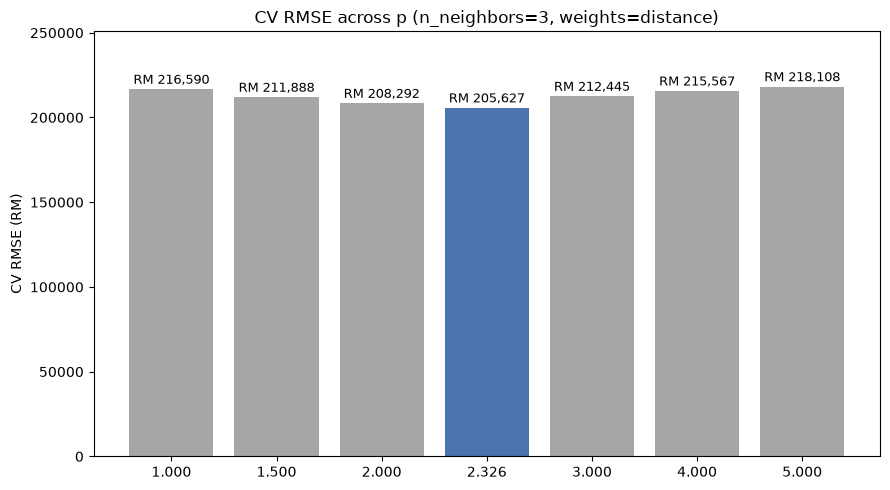

p=1.000: CV RMSE=RM216,590
p=1.500: CV RMSE=RM211,888
p=2.000: CV RMSE=RM208,292
p=2.326: CV RMSE=RM205,627
p=3.000: CV RMSE=RM212,445
p=4.000: CV RMSE=RM215,567
p=5.000: CV RMSE=RM218,108


In [9]:
best = bayes_search.best_params_
p_candidates = sorted({1.0, 1.5, 2.0, 3.0, 4.0, 5.0, best["knn__p"]})
cv_rmse_by_p = []

for p in p_candidates:
    if p == best["knn__p"]:
        cv_rmse_by_p.append(cv_results["mean"]["RMSE"])
        continue
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=best["knn__n_neighbors"], weights=best["knn__weights"], p=p)),
    ])
    cv = cross_validate_model(pipeline, X_train, y_train, n_splits=5)
    cv_rmse_by_p.append(cv["mean"]["RMSE"])

p_labels = [f"{p:.3f}" for p in p_candidates]
colors = ["#4c72b0" if p == best["knn__p"] else "#a6a6a6" for p in p_candidates]

plt.figure(figsize=(9, 5))
plt.bar(p_labels, cv_rmse_by_p, color=colors)
plt.ylabel("CV RMSE (RM)")
plt.title(f"CV RMSE across p (n_neighbors={best['knn__n_neighbors']}, weights={best['knn__weights']})")
plt.ylim(0, max(cv_rmse_by_p) * 1.15)
for i, v in enumerate(cv_rmse_by_p):
    plt.text(i, v + max(cv_rmse_by_p) * 0.015, f"RM {v:,.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

for p, r in zip(p_labels, cv_rmse_by_p):
    print(f"p={p}: CV RMSE=RM{r:,.0f}")


## Effect of weights

5-fold CV (mean +/- std):
  RMSE:  RM 208,127 +/- 19,203  (59.2% of median price)
  MAE:   RM 102,847 +/- 3,688
  MAPE:  24.2% +/- 1.5%
  R2:    0.5883 +/- 0.0302


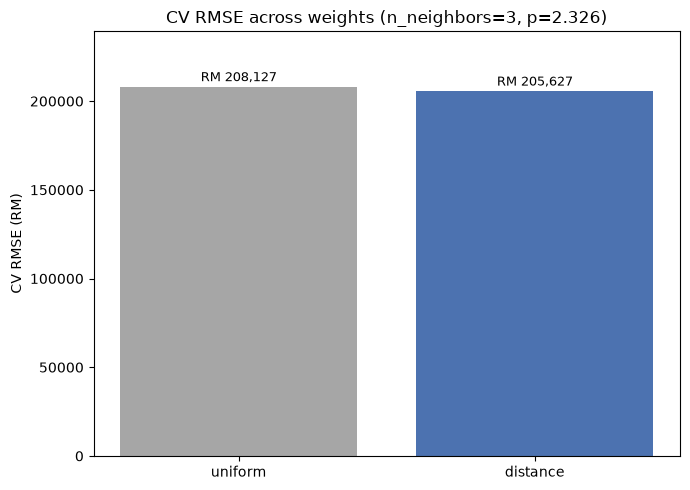

weights=uniform: CV RMSE=RM208,127
weights=distance: CV RMSE=RM205,627


In [10]:
best = bayes_search.best_params_
weight_candidates = ["uniform", "distance"]
cv_rmse_by_w = []

for w in weight_candidates:
    if w == best["knn__weights"]:
        cv_rmse_by_w.append(cv_results["mean"]["RMSE"])
        continue
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=best["knn__n_neighbors"], weights=w, p=best["knn__p"])),
    ])
    cv = cross_validate_model(pipeline, X_train, y_train, n_splits=5)
    cv_rmse_by_w.append(cv["mean"]["RMSE"])

colors = ["#4c72b0" if w == best["knn__weights"] else "#a6a6a6" for w in weight_candidates]

plt.figure(figsize=(7, 5))
plt.bar(weight_candidates, cv_rmse_by_w, color=colors)
plt.ylabel("CV RMSE (RM)")
plt.title(f"CV RMSE across weights (n_neighbors={best['knn__n_neighbors']}, p={best['knn__p']:.3f})")
plt.ylim(0, max(cv_rmse_by_w) * 1.15)
for i, v in enumerate(cv_rmse_by_w):
    plt.text(i, v + max(cv_rmse_by_w) * 0.015, f"RM {v:,.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

for w, r in zip(weight_candidates, cv_rmse_by_w):
    print(f"weights={w}: CV RMSE=RM{r:,.0f}")
